In [1]:
# add_cna_signal.ipynb - add CNA signals to adata count data.

In [2]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from sccnasim.xlib.xrange import format_chrom

In [3]:
in_adata_fn = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/afc_scdesign2_copula/raw_matrix/scDesign2_copula.raw_matrix.h5ad"
cna_profile_fn = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/data/cna_profile.tsv"

out_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/afc_scdesign2_copula/cna_matrix"
out_adata_fn = os.path.join(out_dir, "scDesign2_copula.cna_matrix.h5ad")

## Load data

In [4]:
adata = ad.read_h5ad(in_adata_fn)
adata

/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 1200 × 32286
    obs: 'cell', 'cell_type'
    var: 'gene_id', 'gene', 'chrom', 'start', 'end', 'strand'

In [5]:
adata.X = adata.X.astype('float32')

In [6]:
adata.var['chrom'] = adata.var['chrom'].map(str)
adata.var

,gene_id,gene,chrom,start,end,strand
0,ENSG00000243485,MIR1302-2HG,1,29554,31109,+
1,ENSG00000237613,FAM138A,1,34554,36081,-
2,ENSG00000186092,OR4F5,1,65419,71585,+
3,ENSG00000238009,AL627309.1,1,89295,133723,-
4,ENSG00000239945,AL627309.3,1,89551,91105,-
...,...,...,...,...,...,...
32281,ENSG00000203993,ARRDC1-AS1,9,137615332,137618906,-
32282,ENSG00000181090,EHMT1,9,137618963,137870016,+
32283,ENSG00000203987,AL772363.1,9,137867925,137892570,-
32284,ENSG00000148408,CACNA1B,9,137877789,138124624,+


In [7]:
cna_profile = pd.read_csv(cna_profile_fn, sep = '\t', header = None, dtype = {0:str})
cna_profile.columns = ['chrom', 'start', 'end', 'clone', 'cn0', 'cn1']
cna_profile

,chrom,start,end,clone,cn0,cn1
0,chr1,123400001,248956422,tumor,1,2
1,chr4,50000001,190214555,tumor,0,1
2,chr8,1,45200000,tumor,0,1
3,chr8,45200001,145138636,tumor,1,2
4,chr13,17700001,114364328,tumor,2,0
5,chr17,1,25100000,tumor,2,0


In [8]:
cna_profile['region'] = cna_profile['chrom'] + ':' + cna_profile['start'].map(str) + '-' + cna_profile['end'].map(str)
cna_profile

cna_profile['cna_type'] = 'N.A.'
cna_profile.loc[cna_profile['cn0'] + cna_profile['cn1'] > 2, 'cna_type'] = 'gain'
cna_profile.loc[cna_profile['cn0'] + cna_profile['cn1'] < 2, 'cna_type'] = 'loss'
cna_profile.loc[cna_profile['cn0'] + cna_profile['cn1'] == 2, 'cna_type'] = 'loh'
cna_profile

,chrom,start,end,clone,cn0,cn1,region,cna_type
0,chr1,123400001,248956422,tumor,1,2,chr1:123400001-248956422,gain
1,chr4,50000001,190214555,tumor,0,1,chr4:50000001-190214555,loss
2,chr8,1,45200000,tumor,0,1,chr8:1-45200000,loss
3,chr8,45200001,145138636,tumor,1,2,chr8:45200001-145138636,gain
4,chr13,17700001,114364328,tumor,2,0,chr13:17700001-114364328,loh
5,chr17,1,25100000,tumor,2,0,chr17:1-25100000,loh


## Find CNA genes

In [9]:
def get_overlap_genes(df, anno):
    df["chrom"] = df["chrom"].map(format_chrom)
    anno["chrom"] = anno["chrom"].map(format_chrom)

    df = df.drop_duplicates("region", ignore_index = True)
    anno = anno.drop_duplicates("gene", ignore_index = True)

    overlap = df.groupby("region").apply(
        lambda x: anno.loc[
            (anno["chrom"] == x["chrom"].values[0]) &
            (anno["start"] <= x["end"].values[0]) &
            (anno["end"] >= x["start"].values[0])
        ]).reset_index()
    
    if 'level_1' in overlap.columns:
        overlap.drop(columns = ['level_1'], inplace = True)
    overlap = overlap.merge(df[['region', 'cn0', 'cn1', 'cna_type']], on = 'region', how = 'left')

    stat = overlap.groupby("gene").size().reset_index(name = "n_overlap_region")
    dup = stat[stat["n_overlap_region"] > 1]
    uniq = stat[stat["n_overlap_region"] == 1].merge(overlap, on = "gene", how = "left")
    uniq = uniq.sort_values(by = ["region", 'chrom', 'start', 'end', 'gene'])

    res = dict(
        # overlap : pandas.DataFrame
        #   The overlapping results. It contains two columns:
        #   - "region": region ID.
        #   - "gene": name of genes overlapping the region.
        overlap = overlap,

        # n_region : int
        #   Number of unique regions.
        n_region = df.shape[0],

        # n_region_overlap : int
        #   Number of unique regions that have overlapping genes.
        n_region_overlap = len(overlap["region"].unique()),

        # n_gene : int
        #   Number of unique genes.
        n_gene = anno.shape[0],

        # n_gene_overlap : int
        #   Number of unique genes that have overlapping regions.
        n_gene_overlap = len(overlap["gene"].unique()),

        # n_gene_dup : int
        #   Number of genes overlapping more than 1 regions.
        n_gene_dup = dup.shape[0],

        # overlap_uniq : pandas.DataFrame
        #   The overlapping results.
        #   Similar to `overlap`, but the genes overlapping more than 1 regions
        #   are removed.
        overlap_uniq = uniq
    )

    return(res)

In [10]:
res = get_overlap_genes(df = cna_profile, anno = adata.var.copy())

/tmp/pbs.1791892.xomics/ipykernel_67339/1258343097.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overlap = df.groupby("region").apply(


In [11]:
res.keys()

dict_keys(['overlap', 'n_region', 'n_region_overlap', 'n_gene', 'n_gene_overlap', 'n_gene_dup', 'overlap_uniq'])

In [12]:
res['overlap']

,region,gene_id,gene,chrom,start,end,strand,cn0,cn1,cna_type
0,chr13:17700001-114364328,ENSG00000279516,FAM230C,13,18195297,18232024,+,2,0,loh
1,chr13:17700001-114364328,ENSG00000231238,LINC00349,13,18540497,18550697,+,2,0,loh
2,chr13:17700001-114364328,ENSG00000229788,LINC00388,13,18610298,18611675,-,2,0,loh
3,chr13:17700001-114364328,ENSG00000231914,LINC00387,13,18672827,18676163,+,2,0,loh
4,chr13:17700001-114364328,ENSG00000226250,LINC00408,13,18905439,18907810,+,2,0,loh
...,...,...,...,...,...,...,...,...,...,...
4964,chr8:45200001-145138636,ENSG00000196150,ZNF250,8,144876497,144902168,-,1,2,gain
4965,chr8:45200001-145138636,ENSG00000170631,ZNF16,8,144930358,144950888,-,1,2,gain
4966,chr8:45200001-145138636,ENSG00000255164,AF235103.1,8,144992914,144994837,+,1,2,gain
4967,chr8:45200001-145138636,ENSG00000255559,ZNF252P-AS1,8,145002811,145006046,+,1,2,gain


In [13]:
res['overlap_uniq']

,gene,n_overlap_region,region,gene_id,chrom,start,end,strand,cn0,cn1,cna_type
2404,FAM230C,1,chr13:17700001-114364328,ENSG00000279516,13,18195297,18232024,+,2,0,loh
2958,LINC00349,1,chr13:17700001-114364328,ENSG00000231238,13,18540497,18550697,+,2,0,loh
2986,LINC00388,1,chr13:17700001-114364328,ENSG00000229788,13,18610298,18611675,-,2,0,loh
2985,LINC00387,1,chr13:17700001-114364328,ENSG00000231914,13,18672827,18676163,+,2,0,loh
3000,LINC00408,1,chr13:17700001-114364328,ENSG00000226250,13,18905439,18907810,+,2,0,loh
...,...,...,...,...,...,...,...,...,...,...,...
4929,ZNF250,1,chr8:45200001-145138636,ENSG00000196150,8,144876497,144902168,-,1,2,gain
4926,ZNF16,1,chr8:45200001-145138636,ENSG00000170631,8,144930358,144950888,-,1,2,gain
1170,AF235103.1,1,chr8:45200001-145138636,ENSG00000255164,8,144992914,144994837,+,1,2,gain
4931,ZNF252P-AS1,1,chr8:45200001-145138636,ENSG00000255559,8,145002811,145006046,+,1,2,gain


In [14]:
res['overlap_uniq']['cna_type'].value_counts()

cna_type
gain    2303
loss    1438
loh     1228
Name: count, dtype: int64

In [15]:
res['overlap'].to_csv(
    os.path.join(out_dir, 'cna_genes.tsv'),
    sep = '\t',
    index = False
)

In [16]:
res['overlap_uniq'].to_csv(
    os.path.join(out_dir, 'cna_genes.unique.tsv'),
    sep = '\t',
    index = False
)

## Add copy gain signals

In [17]:
df = res['overlap_uniq']
cna_genes = df.loc[df['cna_type'] == 'gain', 'gene'].to_numpy()
print(cna_genes.shape)
cna_genes[:10]

(2303,)


array(['AC239859.3', 'AC239800.2', 'AC239800.3', 'AC239798.2',
       'AC246680.1', 'HIST2H3PS2', 'FAM72C', 'IGKV1OR1-1', 'AC245595.1',
       'PPIAL4E'], dtype=object)

In [18]:
idx = np.ix_(adata.obs['cell_type'] == 'tumor', adata.var['gene'].isin(cna_genes))
print(adata.X[idx].shape)
adata.X[idx] = adata.X[idx] * 1.5
X_tumor = adata.X[idx]

(600, 2303)


In [19]:
idx = np.ix_(adata.obs['cell_type'] == 'normal', adata.var['gene'].isin(cna_genes))
X_normal = adata.X[idx]

In [20]:
fc = ( X_tumor.mean(axis = 0)*1e6 ) / ( X_normal.mean(axis = 0)*1e6 + 1e-8 )
fc[fc > 4] = 4
RD = np.log10(X_normal.mean(axis = 0) + 1)

Text(0, 0.5, 'Gene Fold Change (tumor vs. normal)')

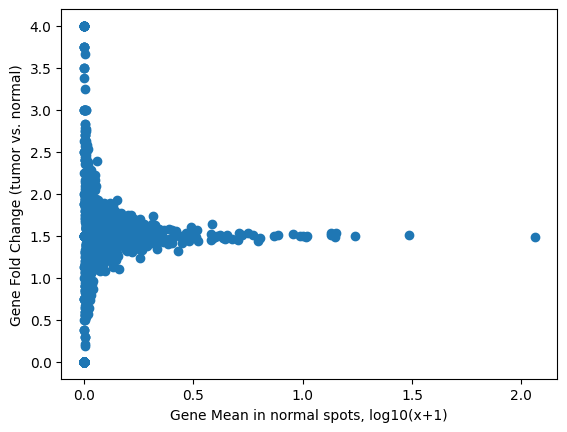

In [21]:
plt.scatter(RD, fc)
plt.xlabel('Gene Mean in normal spots, log10(x+1)')
plt.ylabel('Gene Fold Change (tumor vs. normal)')

## Add copy loss signals

In [22]:
df = res['overlap_uniq']
cna_genes = df.loc[df['cna_type'] == 'loss', 'gene'].to_numpy()
print(cna_genes.shape)
cna_genes[:10]

(1438,)


array(['DCUN1D4', 'AC027271.1', 'LRRC66', 'SGCB', 'LINC02480', 'SPATA18',
       'USP46', 'USP46-AS1', 'AC104066.2', 'ERVMER34-1'], dtype=object)

In [23]:
idx = np.ix_(adata.obs['cell_type'] == 'tumor', adata.var['gene'].isin(cna_genes))
print(adata.X[idx].shape)
adata.X[idx] = adata.X[idx] * 0.5
X_tumor = adata.X[idx]

(600, 1438)


In [24]:
idx = np.ix_(adata.obs['cell_type'] == 'normal', adata.var['gene'].isin(cna_genes))
X_normal = adata.X[idx]

In [25]:
fc = ( X_tumor.mean(axis = 0)*1e6 ) / ( X_normal.mean(axis = 0)*1e6 + 1e-8 )
fc[fc > 4] = 4
RD = np.log10(X_normal.mean(axis = 0) + 1)

Text(0, 0.5, 'Gene Fold Change (tumor vs. normal)')

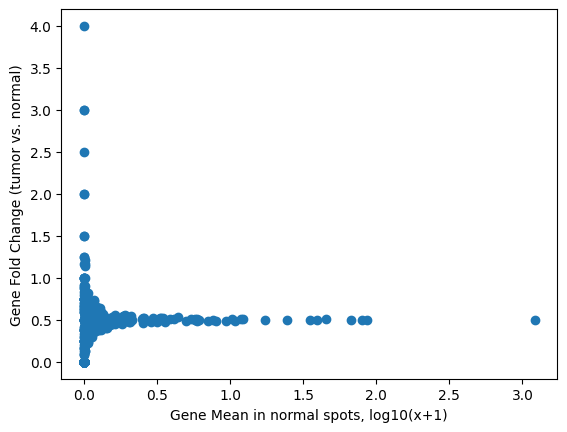

In [26]:
plt.scatter(RD, fc)
plt.xlabel('Gene Mean in normal spots, log10(x+1)')
plt.ylabel('Gene Fold Change (tumor vs. normal)')

## Save adata

In [27]:
adata.var

,gene_id,gene,chrom,start,end,strand
0,ENSG00000243485,MIR1302-2HG,1,29554,31109,+
1,ENSG00000237613,FAM138A,1,34554,36081,-
2,ENSG00000186092,OR4F5,1,65419,71585,+
3,ENSG00000238009,AL627309.1,1,89295,133723,-
4,ENSG00000239945,AL627309.3,1,89551,91105,-
...,...,...,...,...,...,...
32281,ENSG00000203993,ARRDC1-AS1,9,137615332,137618906,-
32282,ENSG00000181090,EHMT1,9,137618963,137870016,+
32283,ENSG00000203987,AL772363.1,9,137867925,137892570,-
32284,ENSG00000148408,CACNA1B,9,137877789,138124624,+


In [28]:
adata.var = adata.var.merge(res['overlap_uniq'][["gene", "region", "cn0", "cn1", "cna_type"]], on = "gene", how = "left")
adata.var

,gene_id,gene,chrom,start,end,strand,region,cn0,cn1,cna_type
0,ENSG00000243485,MIR1302-2HG,1,29554,31109,+,NaN,NaN,NaN,NaN
1,ENSG00000237613,FAM138A,1,34554,36081,-,NaN,NaN,NaN,NaN
2,ENSG00000186092,OR4F5,1,65419,71585,+,NaN,NaN,NaN,NaN
3,ENSG00000238009,AL627309.1,1,89295,133723,-,NaN,NaN,NaN,NaN
4,ENSG00000239945,AL627309.3,1,89551,91105,-,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
32281,ENSG00000203993,ARRDC1-AS1,9,137615332,137618906,-,NaN,NaN,NaN,NaN
32282,ENSG00000181090,EHMT1,9,137618963,137870016,+,NaN,NaN,NaN,NaN
32283,ENSG00000203987,AL772363.1,9,137867925,137892570,-,NaN,NaN,NaN,NaN
32284,ENSG00000148408,CACNA1B,9,137877789,138124624,+,NaN,NaN,NaN,NaN


In [29]:
adata.var['cna_type'].value_counts()

cna_type
gain    2303
loss    1438
loh     1228
Name: count, dtype: int64

In [30]:
adata.write(out_adata_fn, compression = 'gzip')